In [2]:
import sys
sys.path.append('..')

In [11]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from config import small_dataset_path

In [5]:
with h5py.File(small_dataset_path, 'r') as f:
    waveforms = f['waveforms'][:]
waveforms.shape

(200000, 4, 128)

In [7]:
idxs = [183_289, 45, 78_223, 95_389, 16_321, 1_246]
selected_waveforms = waveforms[idxs]
selected_waveforms.shape # (6, 4, 128)
# keep only the first channel so 6 4 128 -> 6 128
selected_waveforms = selected_waveforms[:, 0, :]
selected_waveforms.shape

(6, 128)

In [ ]:
rng = np.random.default_rng(42)

def apply_random_scaling(summed_waveforms):
    scale_min = 0.5
    scale_max = 2.0
    log_scale = rng.uniform(
        np.log(scale_min),
        np.log(scale_max),
    )
    scale = np.exp(log_scale)
    summed_waveforms = summed_waveforms * scale
    return summed_waveforms

def add_random_noise(summed_waveforms):
    noise = rng.normal(0, 1, size=summed_waveforms.shape)
    summed_waveforms = summed_waveforms + noise
    return summed_waveforms

In [44]:
def plot_neon_signal(signal, color='green', smooth_sigma=1.5):
    y = np.array(signal).flatten()
    x = np.arange(len(y))
    
    if smooth_sigma > 0:
        y = gaussian_filter1d(y, sigma=smooth_sigma)
        
    fig, ax = plt.subplots(figsize=(12, 3))
    
    # Ajout de la grille en arrière-plan
    ax.grid(True, linestyle='--', alpha=0.5, color='lightgrey')
    ax.set_axisbelow(True)
    
    # Effet de halo (néon)
    n_glow_lines = 5
    for i in range(n_glow_lines):
        linewidth = 10 - i * 1.5
        alpha = 0.05 + i * 0.05
        ax.plot(x, y, color=color, linewidth=linewidth, alpha=alpha)
        
    # Ligne centrale
    ax.plot(x, y, color=color, linewidth=2, alpha=0.9)
    
    # Ajout des axes
    ax.set_xlabel("Frequency Bin")
    ax.set_ylabel("Strain")

    
    plt.tight_layout()
    plt.show()

In [12]:
summed_waveforms = np.sum(selected_waveforms, axis=0)
print(summed_waveforms.shape)
scaled_summed_waveforms = apply_random_scaling(summed_waveforms)
print(scaled_summed_waveforms.shape)
noised_scale_summed_waveforms = add_random_noise(scaled_summed_waveforms)
print(noised_scale_summed_waveforms.shape)


(128,)
(128,)
(128,)


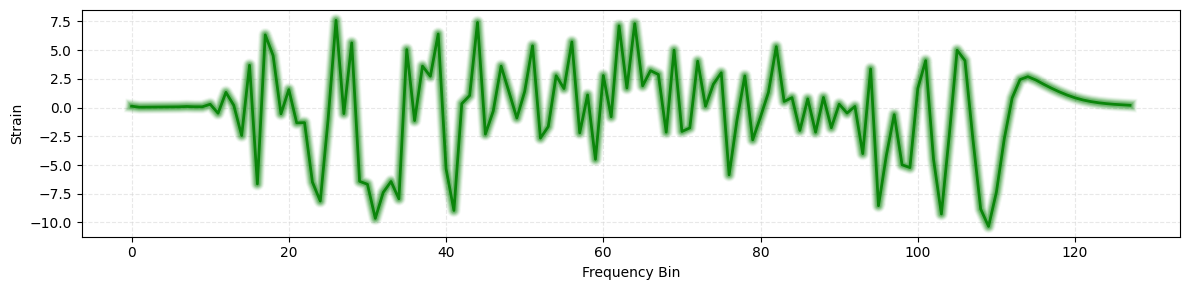

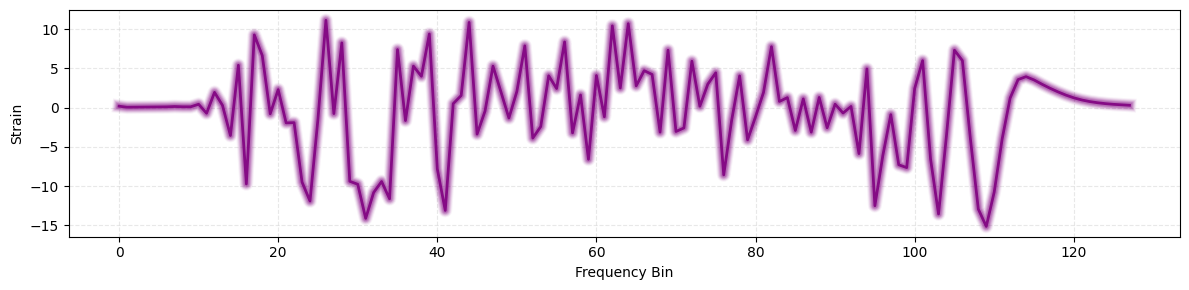

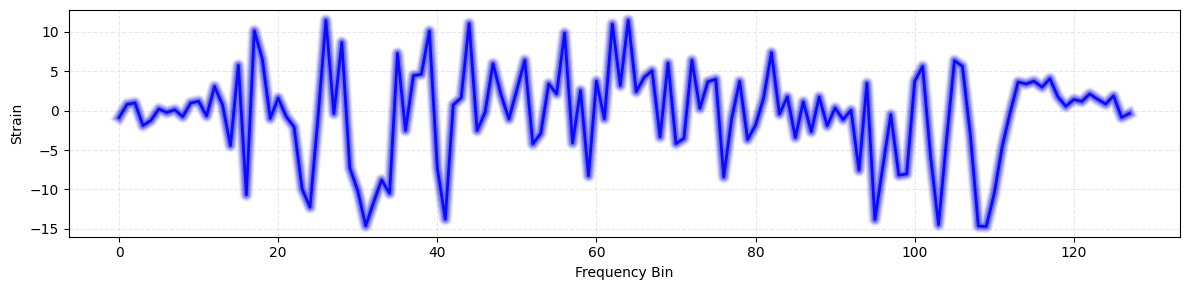

In [46]:
plot_neon_signal(summed_waveforms, color='green', smooth_sigma=0.0)
plot_neon_signal(scaled_summed_waveforms, color='purple', smooth_sigma=0.0)
plot_neon_signal(noised_scale_summed_waveforms, color='blue', smooth_sigma=0.0)